# Chart: Comparing Training, Validation and Test Losses


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week14/chart_comparing_training_validation_and_test_losses.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week14/chart_comparing_training_validation_and_test_losses.ipynb)



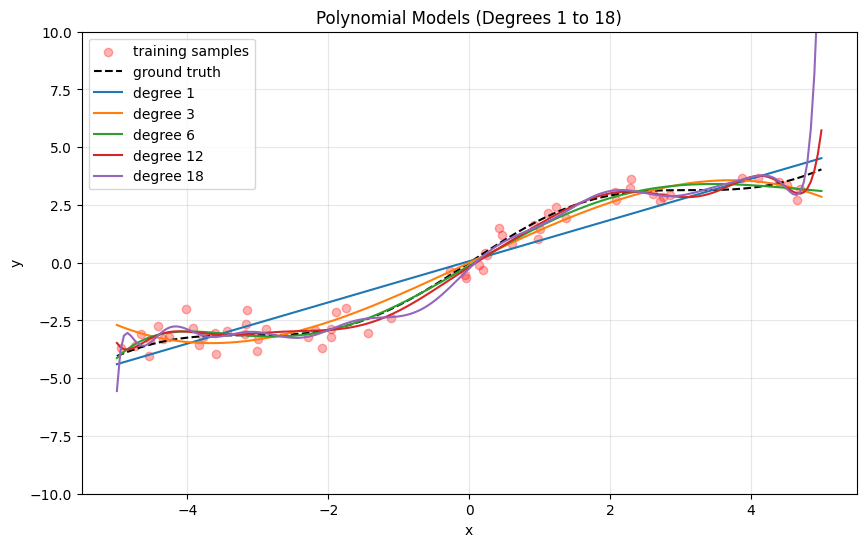

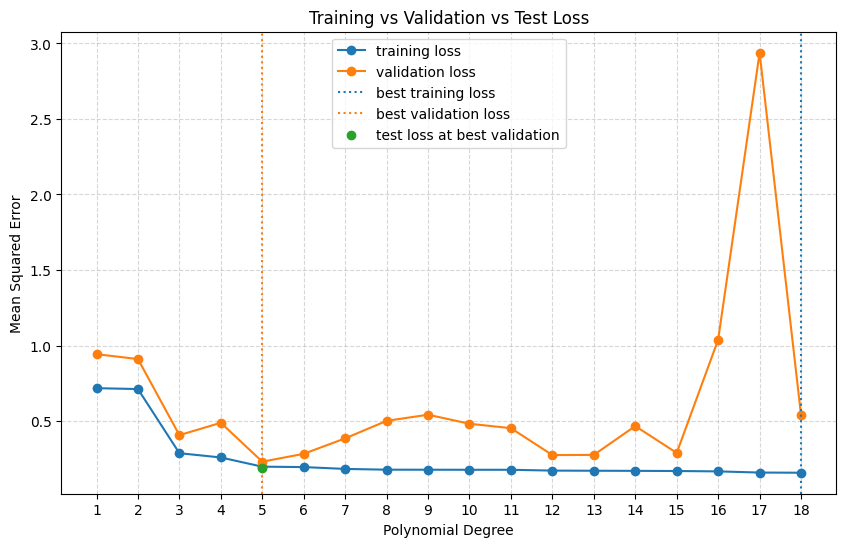

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Setup
np.random.seed(42)
def f(x):
    return x + np.sin(x)

# Generate data: Training, Validation, and Test sets
x_all = np.random.uniform(-5, 5, 100)
y_all = f(x_all) + np.random.normal(scale=0.5, size=100)

x_train_val, x_test, y_train_val, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=42) # 60/20/20 split

xs_plot = np.linspace(-5, 5, 200)
degrees = np.arange(1, 19)

train_losses = []
val_losses = []
models = {}

# 2. Train and evaluate for each degree
for d in degrees:
    coeffs = np.polyfit(x_train, y_train, d)
    model = np.poly1d(coeffs)
    models[d] = model

    train_losses.append(mean_squared_error(y_train, model(x_train)))
    val_losses.append(mean_squared_error(y_val, model(x_val)))

# 3. Chart 1: Polynomial Models
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='red', alpha=0.3, label='training samples')
plt.plot(xs_plot, f(xs_plot), color='black', linestyle='--', label='ground truth')

for d in [1, 3, 6, 12, 18]:
    plt.plot(xs_plot, models[d](xs_plot), label=f'degree {d}')

plt.title("Polynomial Models (Degrees 1 to 18)")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-10, 10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Chart 2: Loss Curves
best_val_deg = degrees[np.argmin(val_losses)]
best_train_deg = degrees[np.argmin(train_losses)]
test_loss_at_best_val = mean_squared_error(y_test, models[best_val_deg](x_test))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_losses, color="C0", marker='o', label='training loss')
plt.plot(degrees, val_losses, color="C1", marker='o', label='validation loss')

# Highlights
plt.axvline(best_train_deg, color="C0", linestyle=':', label=f'best training loss')
plt.axvline(best_val_deg, color="C1", linestyle=':', label=f'best validation loss')
plt.scatter(best_val_deg, test_loss_at_best_val, color='C2', zorder=5, label=f'test loss at best validation')

# plt.yscale('log')
plt.title("Training vs Validation vs Test Loss")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.xticks(degrees)
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()